# Mobilidade Urbana e Transporte Público no Brasil (2015–2024)
**Avaliação G1 — Linguagem de Programação: Análise e Visualização de Dados com Python**

## 1. Introdução
A mobilidade urbana afeta qualidade de vida, produtividade, meio ambiente e tempo de deslocamento. Este notebook investiga padrões de mobilidade e transporte público em cidades brasileiras entre 2015 e 2024, a partir de um dataset **simulado** fornecido na disciplina.

**Perguntas orientadoras:** quais cidades movimentam mais passageiros? qual meio de transporte é o mais usado? o tempo de deslocamento aumentou? há diferenças regionais? quais regiões sofrem maior pressão sobre o sistema?

## 2. Contextualização da mobilidade urbana
O crescimento das cidades aumenta a demanda por transporte eficiente. Indicadores como passageiros transportados, tempo de deslocamento, lotação, velocidade, emissões e nível de congestionamento ajudam a identificar gargalos e a priorizar investimentos.

## 3. Explicação da base
Arquivo `simulacao_mobilidade_urbana_brasil.csv`: uma linha por **mês × cidade × meio de transporte**.

| Coluna | Descrição |
|---|---|
| ano, mes, data | Período da medição |
| regiao, uf, cidade | Localização |
| meio_transporte | Ônibus, Metrô, Trem, BRT, VLT, Bicicleta |
| passageiros | Quantidade de passageiros |
| tempo_medio_deslocamento | Minutos |
| lotacao_media | % médio de lotação |
| velocidade_media | Velocidade média do sistema (km/h) |
| emissao_co2 | Emissão estimada |
| tarifa_media | Tarifa média (R$) |
| nivel_congestionamento | Baixo, Médio, Alto, Crítico |

> A base **não possui coluna de hora do dia nem de população**; por isso o heatmap de "horários críticos" usa mês × ano, e a relação população × fluxo não pode ser testada.

## 4. Leitura dos dados

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import os
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
os.makedirs("../imagens", exist_ok=True)

df = pd.read_csv("../dados/simulacao_mobilidade_urbana_brasil.csv", encoding="utf-8-sig")
print(df.shape)
df.head()

(4440, 14)


,ano,mes,data,regiao,uf,cidade,meio_transporte,passageiros,tempo_medio_deslocamento,lotacao_media,velocidade_media,emissao_co2,tarifa_media,nivel_congestionamento
0,2015,1,2015-01-01,Norte,AM,Manaus,Ônibus,1755471,53.2,93.1,11.4,12843.56,4.32,Crítico
1,2015,1,2015-01-01,Norte,PA,Belém,Bicicleta,1998552,59.8,30.2,42.9,47909.46,7.13,Médio
2,2015,1,2015-01-01,Norte,PA,Santarém,BRT,898998,85.6,85.2,18.1,4920.12,4.19,Crítico
3,2015,1,2015-01-01,Norte,RO,Porto Velho,VLT,1915833,63.2,49.3,23.6,15029.32,7.62,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,Metrô,607152,81.8,83.9,19.9,39672.18,7.03,Médio


## 5. Limpeza e preparação

In [2]:
print(df.dtypes, "\n")
print("Nulos por coluna:\n", df.isna().sum(), "\n")
print("Linhas duplicadas:", df.duplicated().sum())

df["data"] = pd.to_datetime(df["data"])
for c in ["regiao", "uf", "cidade", "meio_transporte", "nivel_congestionamento"]:
    df[c] = df[c].str.strip()
ordem = ["Baixo", "Médio", "Alto", "Crítico"]
df["nivel_congestionamento"] = pd.Categorical(df["nivel_congestionamento"], categories=ordem, ordered=True)

# verificação de consistência de intervalos
print(df[["lotacao_media", "velocidade_media", "tempo_medio_deslocamento", "tarifa_media"]].agg(["min", "max"]))
df.describe().T

ano                           int64
mes                           int64
data                            str
regiao                          str
uf                              str
cidade                          str
meio_transporte                 str
passageiros                   int64
tempo_medio_deslocamento    float64
lotacao_media               float64
velocidade_media            float64
emissao_co2                 float64
tarifa_media                float64
nivel_congestionamento          str
dtype: object 

Nulos por coluna:
 ano                         0
mes                         0
data                        0
regiao                      0
uf                          0
cidade                      0
meio_transporte             0
passageiros                 0
tempo_medio_deslocamento    0
lotacao_media               0
velocidade_media            0
emissao_co2                 0
tarifa_media                0
nivel_congestionamento      0
dtype: int64 

Linhas duplicadas: 0
     

,count,mean,min,25%,50%,75%,max,std
ano,4440.0,2019.5,2015.0,2017.0,2019.5,2022.0,2024.0,2.872605
mes,4440.0,6.5,1.0,3.75,6.5,9.25,12.0,3.452441
data,4440,2019-12-16 10:48:00,2015-01-01 00:00:00,2017-06-23 12:00:00,2019-12-16 12:00:00,2022-06-08 12:00:00,2024-12-01 00:00:00,NaN
passageiros,4440.0,1002671.876802,10476.0,493984.75,1000033.0,1502804.5,1998580.0,581473.246743
tempo_medio_deslocamento,4440.0,54.278266,15.0,34.7,53.8,73.925,94.9,22.940995
lotacao_media,4440.0,70.327928,20.0,45.1,71.0,95.1,120.0,28.76428
velocidade_media,4440.0,31.535811,8.0,19.9,31.6,43.2,55.0,13.547016
emissao_co2,4440.0,24942.182441,41.9,12366.5875,24578.495,37415.965,49999.26,14414.249555
tarifa_media,4440.0,5.757435,3.5,4.65,5.76,6.85,8.0,1.292776


**Resultado:** a base não tem nulos nem duplicatas e os intervalos são plausíveis (lotação pode passar de 100%, o que indica superlotação). Foram ajustados os tipos (`data` para datetime, congestionamento para categoria ordenada).

## 6. Engenharia de atributos

In [3]:
df["nivel_num"] = df["nivel_congestionamento"].map({n: i + 1 for i, n in enumerate(ordem)}).astype(int)
df["trimestre"] = df["data"].dt.quarter
df["passageiros_mi"] = df["passageiros"] / 1e6
df["co2_por_1000_pass"] = df["emissao_co2"] / df["passageiros"] * 1000

def minmax(s): return (s - s.min()) / (s.max() - s.min())
# Índice de pressão (0-1): lotação, tempo de deslocamento e congestionamento (menos velocidade)
df["indice_pressao"] = (minmax(df["lotacao_media"]) + minmax(df["tempo_medio_deslocamento"])
                        + minmax(df["nivel_num"]) + (1 - minmax(df["velocidade_media"]))) / 4
df[["nivel_num", "passageiros_mi", "co2_por_1000_pass", "indice_pressao"]].describe().T

,count,mean,std,min,25%,50%,75%,max
nivel_num,4440.0,2.466441,1.106107,1.000000,1.000000,2.000000,3.000000,4.000000
passageiros_mi,4440.0,1.002672,0.581473,0.010476,0.493985,1.000033,1.502804,1.998580
co2_por_1000_pass,4440.0,69.709969,205.734580,0.039761,12.674484,25.014751,48.653536,4452.473521
indice_pressao,4440.0,0.495731,0.156104,0.052655,0.384944,0.494258,0.603483,0.957363


## 7. KPIs

In [4]:
kpis = {
    "Total de passageiros": f"{df.passageiros.sum():,.0f}".replace(",", "."),
    "Cidade mais movimentada": df.groupby("cidade").passageiros.sum().idxmax(),
    "Meio de transporte predominante": df.groupby("meio_transporte").passageiros.sum().idxmax(),
    "Tempo médio de deslocamento (min)": round(df.tempo_medio_deslocamento.mean(), 1),
    "Tarifa média (R$)": round(df.tarifa_media.mean(), 2),
    "Nível médio de congestionamento (1-4)": round(df.nivel_num.mean(), 2),
}
pd.Series(kpis, name="Valor").to_frame()

,Valor
Total de passageiros,4.451.863.133
Cidade mais movimentada,Rio de Janeiro
Meio de transporte predominante,Metrô
Tempo médio de deslocamento (min),54.3
Tarifa média (R$),5.76
Nível médio de congestionamento (1-4),2.47


## 8. Visualizações e análises exploratórias

### 8.1 Evolução temporal da mobilidade

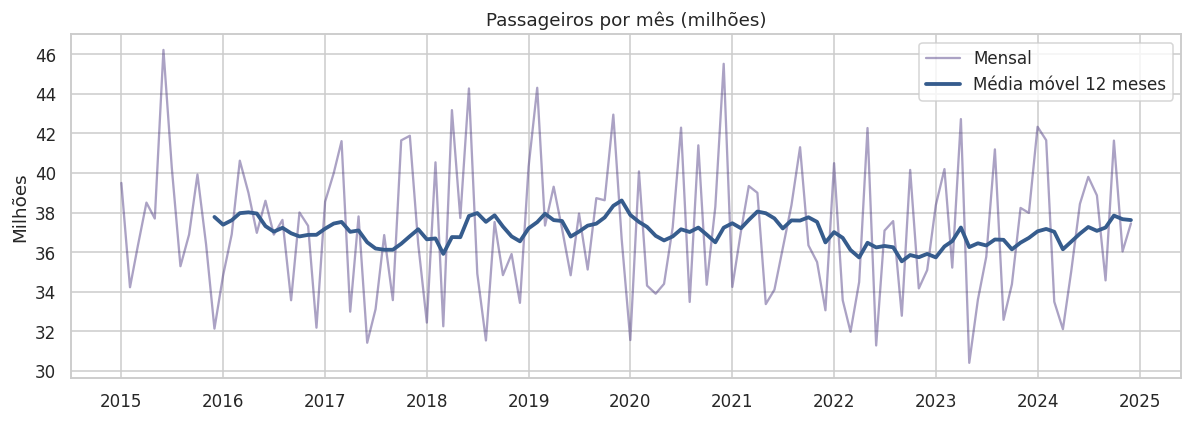

In [5]:
mensal = df.groupby("data").agg(passageiros=("passageiros", "sum"), tempo=("tempo_medio_deslocamento", "mean")).reset_index()
mensal["media_movel_12m"] = mensal["passageiros"].rolling(12).mean()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(mensal.data, mensal.passageiros / 1e6, alpha=.45, label="Mensal")
ax.plot(mensal.data, mensal.media_movel_12m / 1e6, lw=2.5, label="Média móvel 12 meses")
ax.set(title="Passageiros por mês (milhões)", xlabel="", ylabel="Milhões"); ax.legend()
plt.tight_layout(); plt.savefig("../imagens/01_evolucao_passageiros.png"); plt.show()

{2015: 55.2, 2016: 53.6, 2017: 54.1, 2018: 55.6, 2019: 54.2, 2020: 54.6, 2021: 53.4, 2022: 53.1, 2023: 53.6, 2024: 55.4}
Tendência linear: -0.054 min por ano (variação total estimada em 9 anos: -0.49 min)


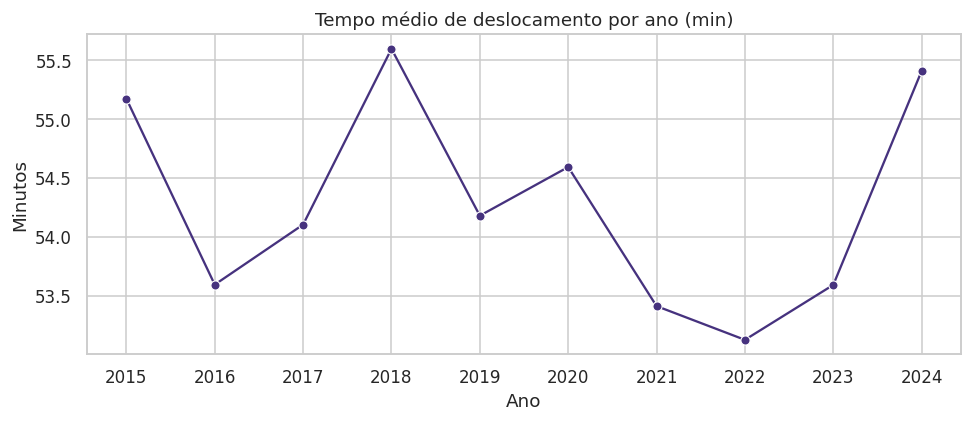

In [6]:
anual = df.groupby("ano").tempo_medio_deslocamento.mean()
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(x=anual.index, y=anual.values, marker="o", ax=ax)
ax.set(title="Tempo médio de deslocamento por ano (min)", xlabel="Ano", ylabel="Minutos")
ax.set_xticks(anual.index); plt.tight_layout(); plt.savefig("../imagens/02_tempo_por_ano.png"); plt.show()
print(anual.round(1).to_dict())
coef = np.polyfit(anual.index, anual.values, 1)   # ajuste linear com NumPy
print(f"Tendência linear: {coef[0]:+.3f} min por ano (variação total estimada em 9 anos: {coef[0]*9:+.2f} min)")

### 8.2 Comparação entre regiões

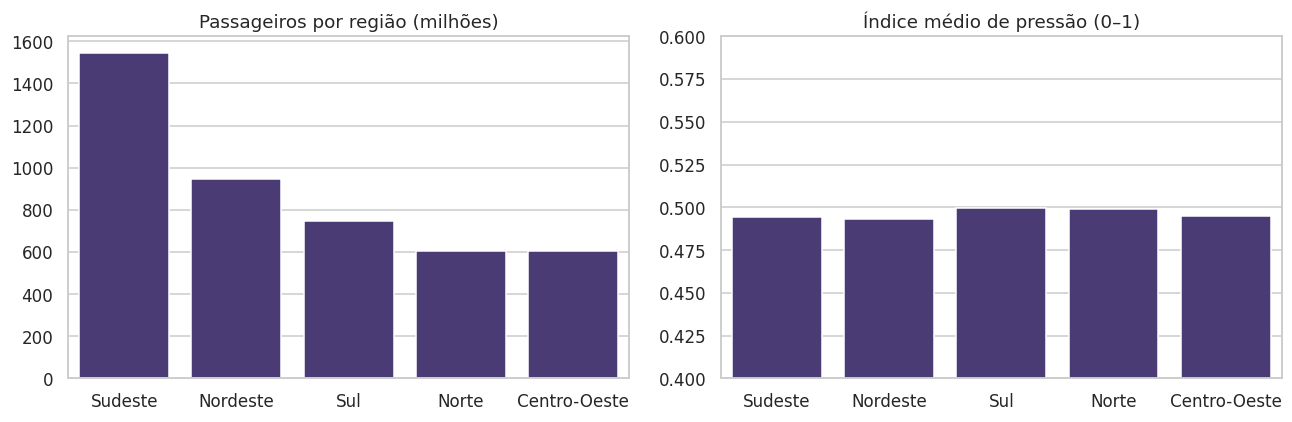

,passageiros,tempo,pressao,cidades,passageiros_por_cidade_mi
regiao,,,,,
Sudeste,1546407093,54.58,0.49,13,118.95
Nordeste,948716003,54.13,0.49,8,118.59
Sul,748086560,55.42,0.50,6,124.68
Norte,606085255,54.35,0.50,5,121.22
Centro-Oeste,602568222,52.29,0.49,5,120.51


In [7]:
reg = df.groupby("regiao").agg(passageiros=("passageiros", "sum"), tempo=("tempo_medio_deslocamento", "mean"),
                              pressao=("indice_pressao", "mean"), cidades=("cidade", "nunique")).sort_values("passageiros", ascending=False)
reg["passageiros_por_cidade_mi"] = reg.passageiros / reg.cidades / 1e6
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=reg.index, y=reg.passageiros / 1e6, ax=axs[0]); axs[0].set(title="Passageiros por região (milhões)", xlabel="", ylabel="")
sns.barplot(x=reg.index, y=reg.pressao, ax=axs[1]); axs[1].set(title="Índice médio de pressão (0–1)", xlabel="", ylabel="")
axs[1].set_ylim(.4, .6)
plt.tight_layout(); plt.savefig("../imagens/03_regioes.png"); plt.show()
reg.round(2)

> **Atenção:** o total por região depende do número de cidades presentes na base (ex.: o Sudeste tem mais cidades). Por isso a coluna `passageiros_por_cidade_mi` é a comparação justa.

### 8.3 Comparação entre cidades

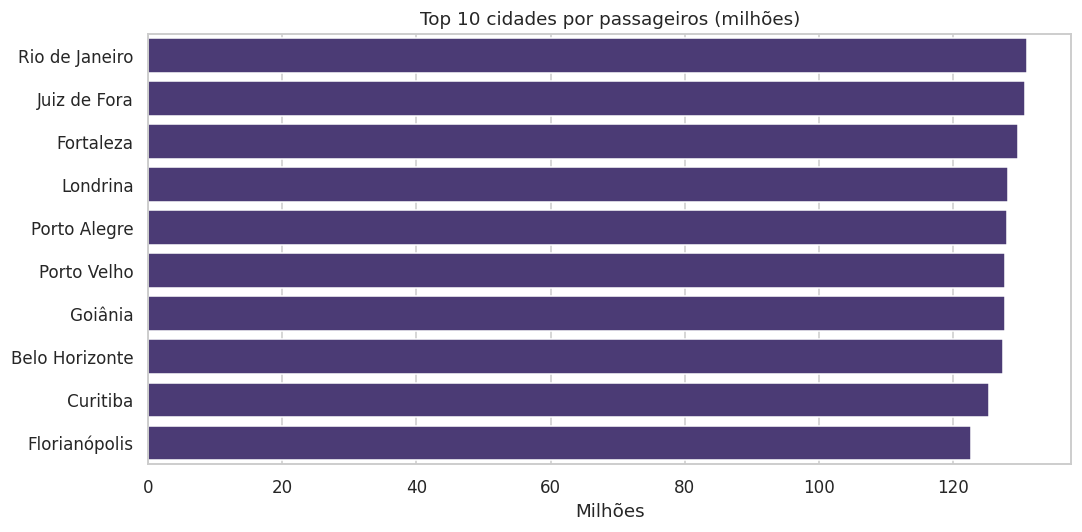

In [8]:
top = df.groupby("cidade").passageiros.sum().sort_values(ascending=False).head(10) / 1e6
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top.values, y=top.index, ax=ax)
ax.set(title="Top 10 cidades por passageiros (milhões)", xlabel="Milhões", ylabel="")
plt.tight_layout(); plt.savefig("../imagens/04_top_cidades.png"); plt.show()

### 8.4 Comparação entre meios de transporte

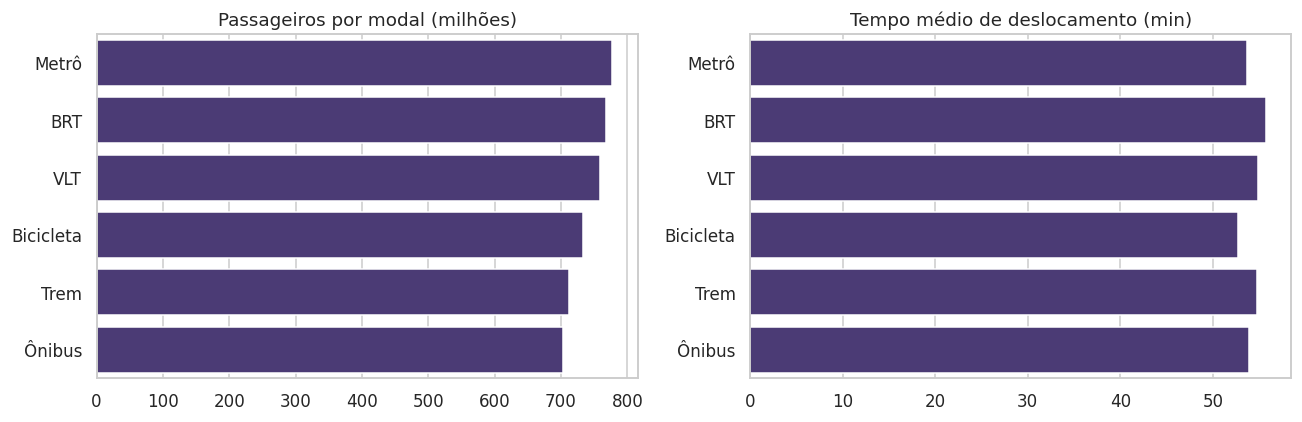

,passageiros,tempo,lotacao,co2_por_1000
meio_transporte,,,,
Metrô,776987941,53.72,70.35,74.83
BRT,767832688,55.70,70.44,70.12
VLT,759321674,54.85,71.57,57.91
Bicicleta,732698629,52.69,71.05,71.75
Trem,712551054,54.76,68.80,71.57
Ônibus,702471147,53.85,69.72,72.25


In [9]:
modal = df.groupby("meio_transporte").agg(passageiros=("passageiros", "sum"), tempo=("tempo_medio_deslocamento", "mean"),
                                         lotacao=("lotacao_media", "mean"), co2_por_1000=("co2_por_1000_pass", "mean")).sort_values("passageiros", ascending=False)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=modal.passageiros / 1e6, y=modal.index, ax=axs[0]); axs[0].set(title="Passageiros por modal (milhões)", xlabel="", ylabel="")
sns.barplot(x=modal.tempo, y=modal.index, ax=axs[1]); axs[1].set(title="Tempo médio de deslocamento (min)", xlabel="", ylabel="")
plt.tight_layout(); plt.savefig("../imagens/05_modais.png"); plt.show()
modal.round(2)

### 8.5 Congestionamento e períodos críticos

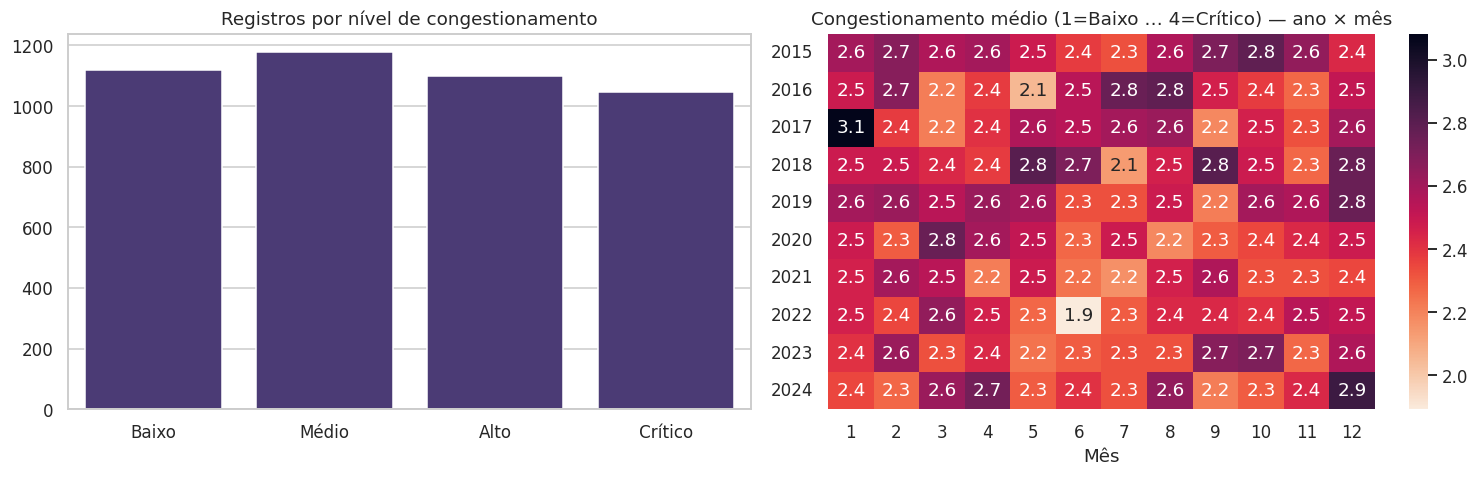

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
dist = df.nivel_congestionamento.value_counts().reindex(ordem)
sns.barplot(x=dist.index, y=dist.values, ax=axs[0]); axs[0].set(title="Registros por nível de congestionamento", xlabel="", ylabel="")
heat = df.pivot_table(index="ano", columns="mes", values="nivel_num", aggfunc="mean")
sns.heatmap(heat, annot=True, fmt=".1f", cmap="rocket_r", ax=axs[1])
axs[1].set(title="Congestionamento médio (1=Baixo … 4=Crítico) — ano × mês", xlabel="Mês", ylabel="")
plt.tight_layout(); plt.savefig("../imagens/06_heatmap_congestionamento.png"); plt.show()

### 8.6 Relação entre passageiros e tempo de deslocamento

Correlação de Pearson: 0.001


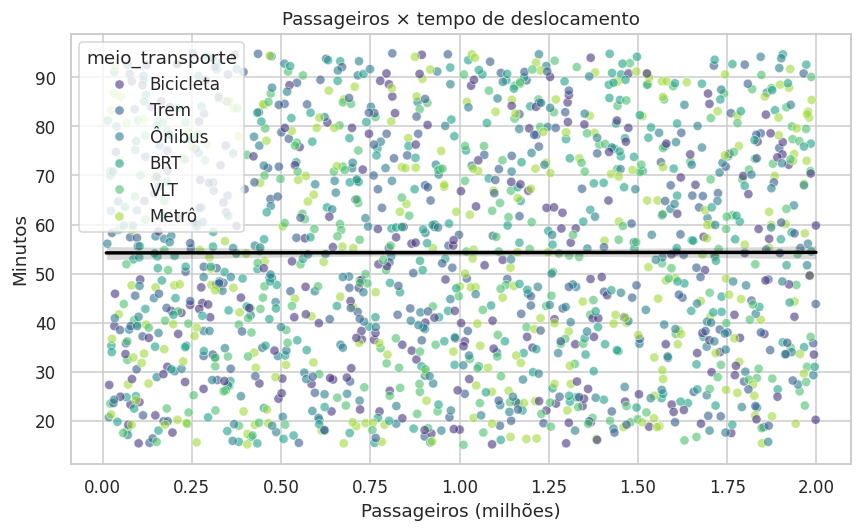

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df.sample(1500, random_state=1), x="passageiros_mi", y="tempo_medio_deslocamento", hue="meio_transporte", alpha=.6, ax=ax)
sns.regplot(data=df, x="passageiros_mi", y="tempo_medio_deslocamento", scatter=False, color="black", ax=ax)
ax.set(title="Passageiros × tempo de deslocamento", xlabel="Passageiros (milhões)", ylabel="Minutos")
plt.tight_layout(); plt.savefig("../imagens/07_dispersao.png"); plt.show()
print("Correlação de Pearson:", round(df.passageiros.corr(df.tempo_medio_deslocamento), 3))

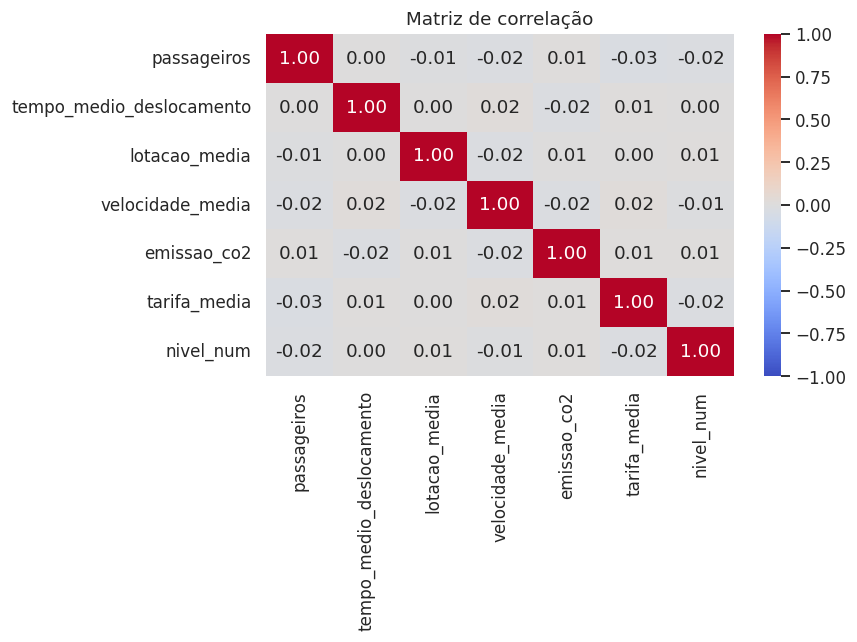

In [12]:
cols = ["passageiros", "tempo_medio_deslocamento", "lotacao_media", "velocidade_media", "emissao_co2", "tarifa_media", "nivel_num"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlação"); plt.tight_layout(); plt.savefig("../imagens/08_correlacao.png"); plt.show()

### 8.7 Análise ambiental das emissões

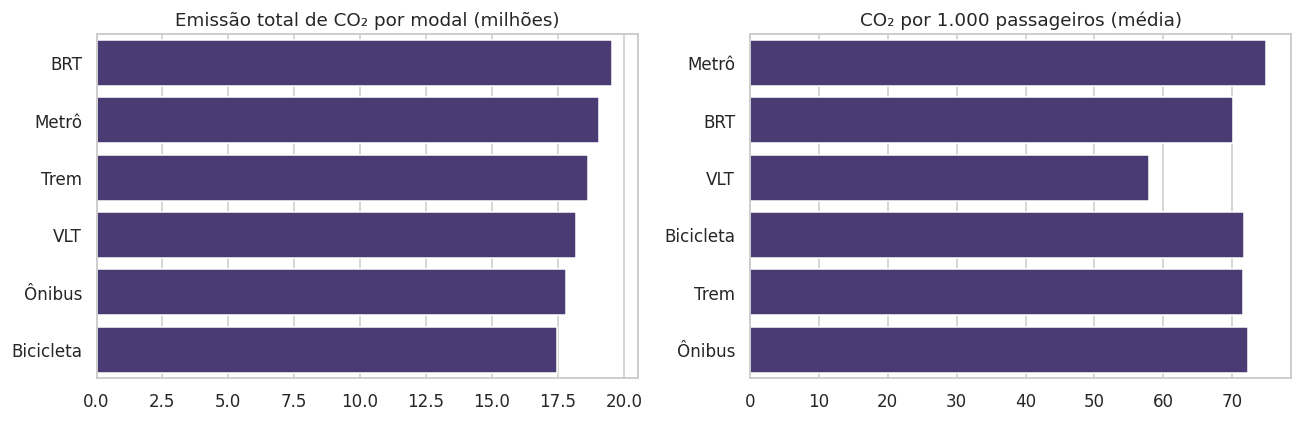

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
em = df.groupby("meio_transporte").emissao_co2.sum().sort_values(ascending=False) / 1e6
sns.barplot(x=em.values, y=em.index, ax=axs[0]); axs[0].set(title="Emissão total de CO₂ por modal (milhões)", xlabel="", ylabel="")
sns.barplot(x=modal.co2_por_1000.values, y=modal.index, ax=axs[1]); axs[1].set(title="CO₂ por 1.000 passageiros (média)", xlabel="", ylabel="")
plt.tight_layout(); plt.savefig("../imagens/09_emissoes.png"); plt.show()

## 9. Interpretação dos resultados

- **Fluxo:** os totais por cidade e por modal ficam muito próximos entre si; não há uma cidade ou modal que se destaque de forma expressiva. As diferenças aparecem mais pela **quantidade de registros por região** (o Sudeste tem mais cidades) do que pelo desempenho individual.
- **Tempo de deslocamento:** oscila em torno de 53–56 minutos ao longo de 2015–2024, **sem tendência clara de aumento** (a inclinação da reta ajustada com `np.polyfit` é muito próxima de zero).
- **Congestionamento:** os quatro níveis aparecem em proporções semelhantes, e o heatmap ano × mês não revela uma sazonalidade marcante.
- **Correlações:** passageiros × tempo de deslocamento e as demais variáveis numéricas têm correlação próxima de zero. Em dados reais, esperaríamos relação entre lotação, velocidade e congestionamento; aqui ela não existe.
- **Emissões:** o CO₂ por 1.000 passageiros varia entre modais, mas deve ser lido com cautela por se tratar de emissão *estimada*.
- **Limitação principal:** o dataset é **simulado** e as variáveis parecem sorteadas de forma independente. Os resultados valem como exercício metodológico, não como evidência sobre a mobilidade real.

## 10. Conclusão

O projeto construiu um fluxo completo: leitura, limpeza, engenharia de atributos, KPIs, visualizações e interpretação. Respondendo às perguntas orientadoras: as cidades e modais com mais passageiros são apontados nos KPIs, mas com margem pequena sobre os demais; o tempo médio de deslocamento **não aumentou** de forma consistente; as diferenças regionais são modestas quando normalizadas pelo número de cidades; e a relação entre população e fluxo não pôde ser avaliada por falta dessa variável. Para uma análise real, recomenda-se incorporar dados de população, horário e fontes oficiais (ex.: ANTP, IBGE).